# 🎯 Project 3: AI Recommendation Logic
## DecodeLabs AI Internship | Batch 2026
### Tech Stack Recommender — Content-Based Filtering Engine

**Dataset:** candidate_job_role_dataset.csv (1000 candidates | 20+ job roles)
**Architecture:** IPO Framework
- INPUT  → candidate_job_role_dataset.csv + User Skills
- PROCESS → TF-IDF Vectorization + Cosine Similarity (4-Step Pipeline)
- OUTPUT → Top-N Ranked Career Recommendations + Skill Gap Analysis

**Algorithm:** Content-Based Filtering

**Similarity Metric:** Cosine Similarity (industry standard)

**Feature Extraction:** TF-IDF Weighting

**Developer:** Kashaf Kamran

In [1]:
import numpy  as np
import pandas as pd

# SKLEARN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise         import cosine_similarity

# VISUALIZATION
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn            as sns

# DISPLAY SETTINGS
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"]     = 120
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows",     30)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
#  LOAD & EXPLORE DATASET

# LOAD CSV
df = pd.read_csv("candidate_job_role_dataset.csv")

# BASIC EXPLORATION
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"\n  File         : candidate_job_role_dataset.csv")
print(f"  Shape        : {df.shape}  (rows × columns)")
print(f"  Columns      : {list(df.columns)}")
print(f"  Missing Values: {df.isnull().sum().sum()}")

print("\n" + "=" * 60)
print("  FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("  JOB ROLE DISTRIBUTION")
print("=" * 60)
role_counts = df["job_role"].value_counts()
print(f"\n  Total Unique Roles : {df['job_role'].nunique()}")
print(f"  Total Candidates   : {len(df)}\n")
print(role_counts.to_string())

print("\n" + "=" * 60)
print("  EXPERIENCE LEVEL DISTRIBUTION")
print("=" * 60)
print(df["experience_level"].value_counts().to_string())

  DATASET OVERVIEW

  File         : candidate_job_role_dataset.csv
  Shape        : (1000, 5)  (rows × columns)
  Columns      : ['candidate_id', 'skills', 'qualification', 'experience_level', 'job_role']
  Missing Values: 0

  FIRST 5 ROWS


,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Communication",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer



  JOB ROLE DISTRIBUTION

  Total Unique Roles : 22
  Total Candidates   : 1000

job_role
Mobile Developer                  75
Data Scientist                    50
Backend Developer                 50
Designer                          50
Full Stack Python Developer       50
Frontend Developer                50
PHP Developer                     50
Game Developer                    50
Full Stack Java Developer         50
DevOps Engineer                   50
Marketing                         50
HR                                50
C# Developer                      50
Blockchain Developer              50
Software Project Manager          50
Cybersecurity Engineer            50
Data Analyst                      50
Web Developer                     49
Kubernetes Operations Engineer    49
AIML                              25
Finance                            1
Video Game Designer                1

  EXPERIENCE LEVEL DISTRIBUTION
experience_level
Mid       401
Senior    351
Entry     247
Entr

In [5]:
# BUILD ROLE PROFILES FROM REAL DATA

def clean_skills(skills_str: str) -> str:
    """
    Cleans a comma-separated skill string:
    - Lowercase everything
    - Strip whitespace
    - Replace spaces within skill names with underscores
    - Return as space-separated string (for TF-IDF tokenizer)

    Example:
        "Python, Machine Learning, SQL"
        → "python machine_learning sql"
    """
    skills = [
        s.strip().lower().replace(" ", "_")
        for s in skills_str.split(",")
    ]
    return " ".join(skills)


# CLEAN ALL CANDIDATE SKILLS
df["skills_clean"] = df["skills"].apply(clean_skills)

# AGGREGATE SKILLS PER JOB ROLE
role_skills_agg = (
    df.groupby("job_role")["skills_clean"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)
role_skills_agg.columns = ["job_role", "combined_skills"]

# CANDIDATE COUNT PER ROLE
candidate_counts = (
    df.groupby("job_role")
    .size()
    .reset_index(name="candidate_count")
)

# EXPERIENCE DISTRIBUTION PER ROLE
# Fixed: compute as a plain dict separately, don't rename columns
exp_dist_dict = (
    df.groupby("job_role")["experience_level"]
    .apply(lambda x: x.value_counts().to_dict())
    .to_dict()
)

# BUILD FINAL ROLE PROFILES DATAFRAME
role_profiles = role_skills_agg.merge(candidate_counts, on="job_role")
role_profiles["experience_dist"] = (
    role_profiles["job_role"].map(exp_dist_dict)
)

# DISPLAY
print("=" * 60)
print("  ROLE PROFILES BUILT FROM REAL DATA")
print("=" * 60)
print(f"\n  Total Job Roles : {len(role_profiles)}")
print(f"  Built from      : {len(df)} real candidate records\n")

for _, row in role_profiles.iterrows():
    skills_preview = row["combined_skills"][:80] + "..."
    print(f"  {row['job_role']:<35} ({row['candidate_count']} candidates)")
    print(f"    Skills: {skills_preview}\n")

  ROLE PROFILES BUILT FROM REAL DATA

  Total Job Roles : 22
  Built from      : 1000 real candidate records

  AIML                                (25 candidates)
    Skills: python machine_learning deep_learning nlp python tensorflow nlp deep_learning py...

  Backend Developer                   (50 candidates)
    Skills: java spring sql rest_apis problem_solving java hibernate sql rest_apis java spri...

  Blockchain Developer                (50 candidates)
    Skills: solidity ethereum javascript blockchain blockchain smart_contracts solidity web3...

  C# Developer                        (50 candidates)
    Skills: c# .net sql asp.net c# .net_core azure sql_server c# asp.net sql_server azure c#...

  Cybersecurity Engineer              (50 candidates)
    Skills: network_security penetration_testing firewalls network_security ethical_hacking ...

  Data Analyst                        (50 candidates)
    Skills: python pandas sql data_visualization sql tableau data_analysis statis

In [6]:
# BUILD TF-IDF MATRIX

# BUILD & FIT VECTORIZER
tfidf_vectorizer = TfidfVectorizer(
    tokenizer     = lambda x: x.split(),
    lowercase     = True,
    token_pattern = None,
    min_df        = 1,   # Include even rare skills
)

# Fit on role profiles → build shared vocabulary space
tfidf_matrix = tfidf_vectorizer.fit_transform(
    role_profiles["combined_skills"]
)

# Extract complete vocabulary
vocabulary = tfidf_vectorizer.get_feature_names_out()

# DISPLAY
print("=" * 60)
print("  TF-IDF MATRIX BUILT FROM REAL DATA")
print("=" * 60)
print(f"\n  Job Roles (rows)      : {tfidf_matrix.shape[0]}")
print(f"  Unique Skills (cols)  : {tfidf_matrix.shape[1]}")
print(f"\n  Complete Skill Vocabulary ({len(vocabulary)} unique skills):")

vocab_sorted = sorted(vocabulary)
for i in range(0, len(vocab_sorted), 6):
    row = vocab_sorted[i:i+6]
    print(f"    {', '.join(row)}")

print(f"\nTF-IDF matrix ready. Shape: {tfidf_matrix.shape}")

  TF-IDF MATRIX BUILT FROM REAL DATA

  Job Roles (rows)      : 22
  Unique Skills (cols)  : 119

  Complete Skill Vocabulary (119 unique skills):
    .net, .net_core, 3d_modeling, adobe_illustrator, adobe_xd, agile
    analytics, android_development, android_sdk, angular, ansible, asp.net
    aws, azure, blockchain, c#, c++, ci/cd
    communication, content_creation, core_data, creativity, css, data_analysis
    data_science, data_visualization, deep_learning, digital_marketing, django, docker
    employee_relations, ethereum, ethical_hacking, excel, express, figma
    financial_modeling, firewalls, flask, game_design, game_physics, gcp
    google_analytics, helm, hibernate, hr_management, hr_policies, html
    ios, ios_development, java, javascript, jenkins, jira
    keras, kotlin, kubernetes, laravel, leadership, linux
    machine_learning, marketing_campaigns, marketing_strategy, microservices, mongodb, mysql
    network_security, nlp, node.js, objective-c, pandas, penetration_test

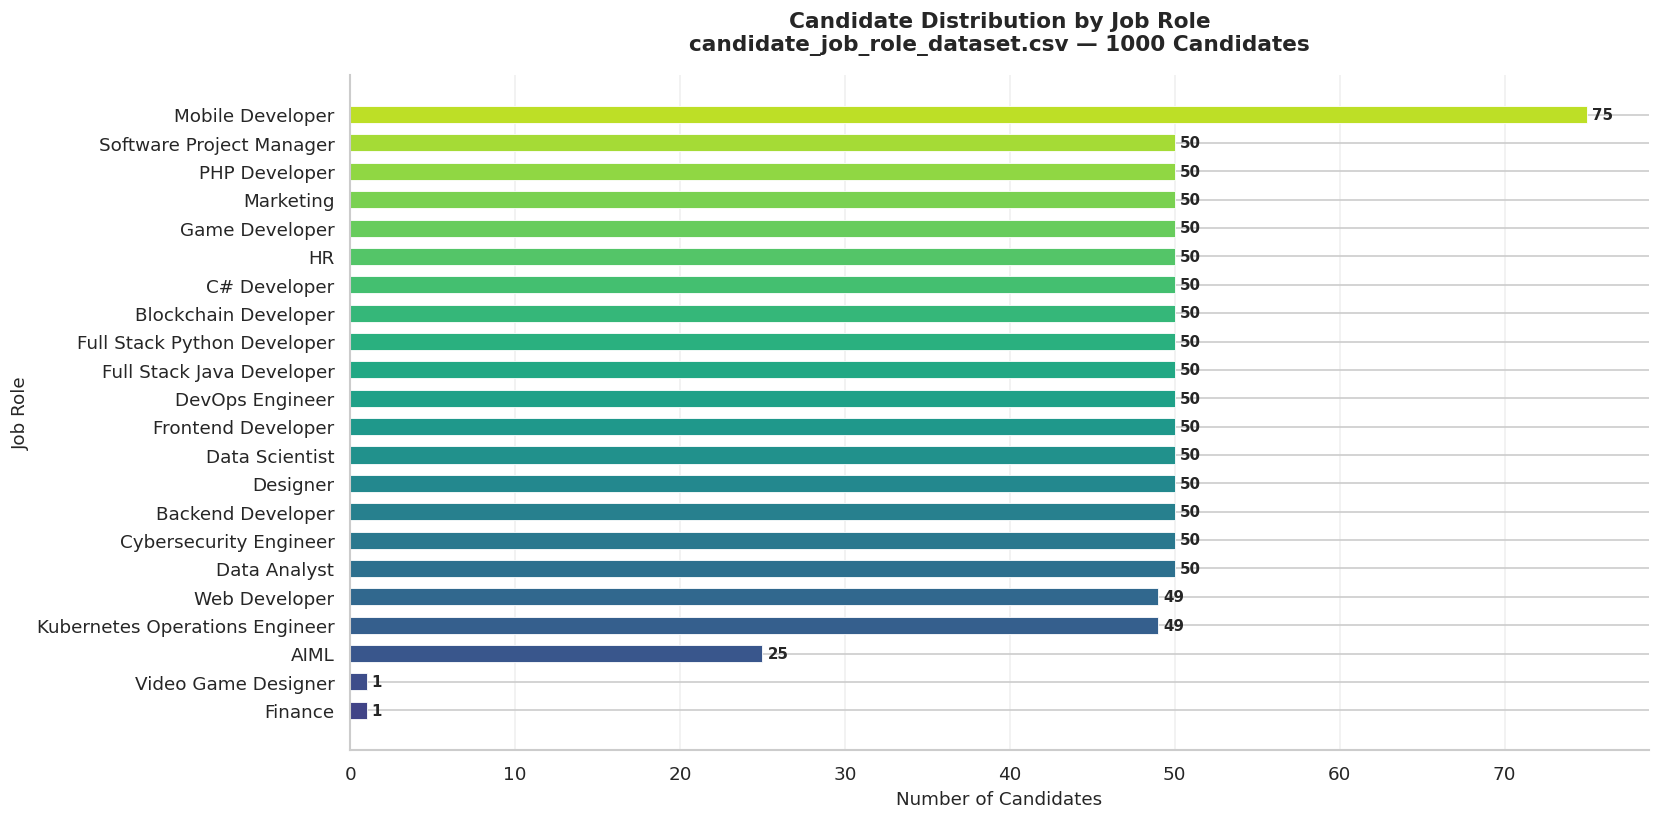


 Dataset contains 22 unique job roles
   across 1000 total candidate records.


In [7]:
# VISUALIZATION 1: JOB ROLE DISTRIBUTION

fig, ax = plt.subplots(figsize=(14, 7))

roles_sorted = role_profiles.sort_values(
    "candidate_count", ascending=True
)

colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(roles_sorted))
)

bars = ax.barh(
    roles_sorted["job_role"],
    roles_sorted["candidate_count"],
    color=colors, height=0.6,
    edgecolor="white", linewidth=0.5
)

# Add count labels
for bar in bars:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center", fontsize=9, fontweight="bold"
    )

ax.set_title(
    "Candidate Distribution by Job Role\n"
    "candidate_job_role_dataset.csv — 1000 Candidates",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Number of Candidates", fontsize=11)
ax.set_ylabel("Job Role",             fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("role_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n Dataset contains {len(role_profiles)} unique job roles")
print(f"   across {len(df)} total candidate records.")

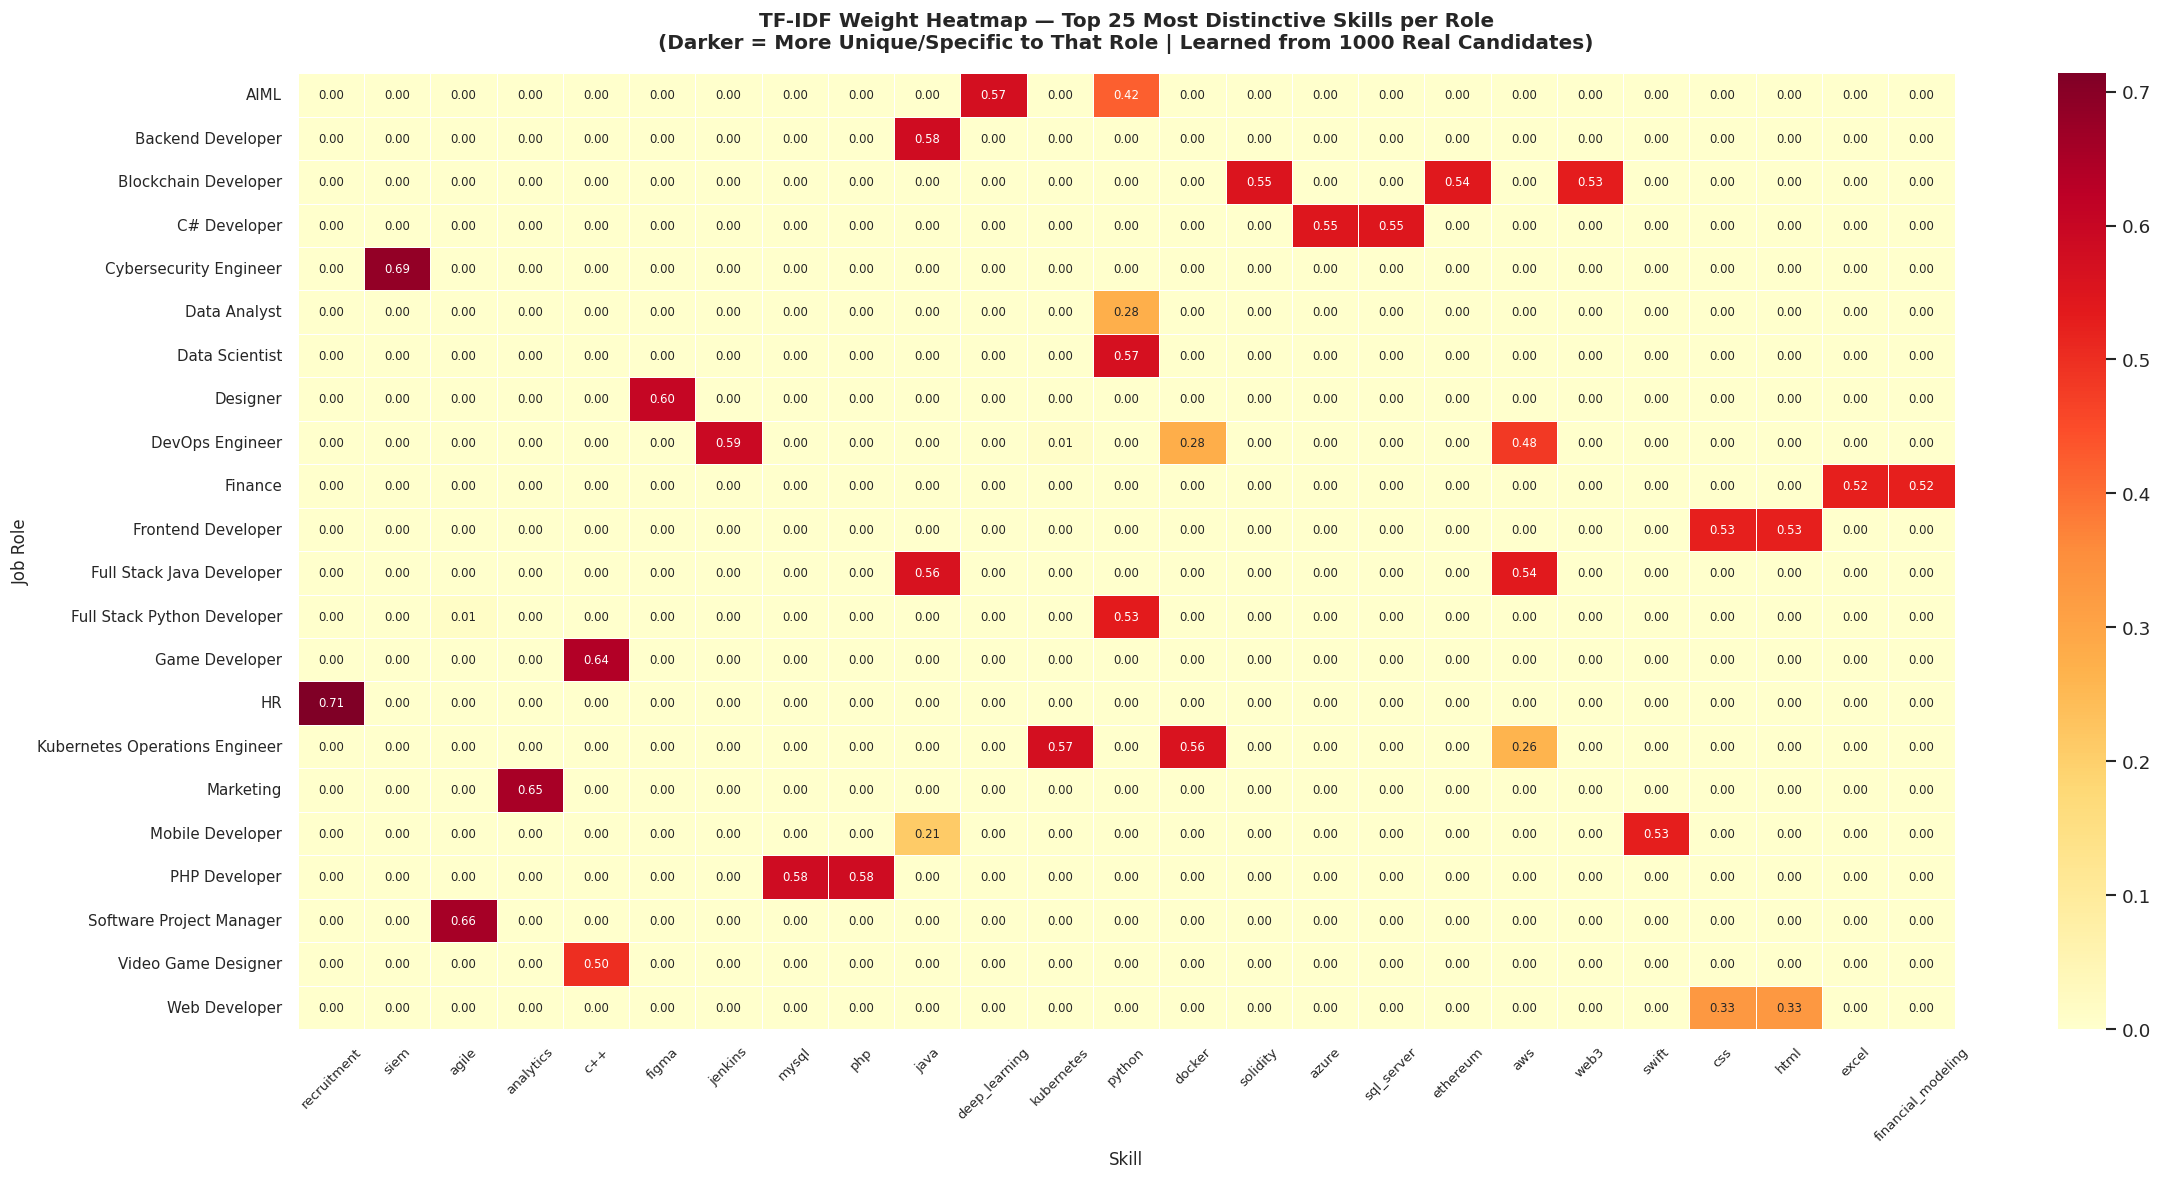


 KEY OBSERVATION:
   Skills appearing in many roles (python, sql, javascript)
   → lower TF-IDF weight (penalized as generic)
   Skills specific to one role (solidity, unreal_engine, siem)
   → higher TF-IDF weight (rewarded as specific)


In [8]:
# VISUALIZATION 2: TF-IDF WEIGHT HEATMAP

# Convert to dense DataFrame
tfidf_dense = pd.DataFrame(
    tfidf_matrix.toarray(),
    index   = role_profiles["job_role"],
    columns = vocabulary,
)

# Select top 25 most distinctive skills
top_skills    = tfidf_dense.max(axis=0).nlargest(25).index
tfidf_top     = tfidf_dense[top_skills]

fig, ax = plt.subplots(figsize=(20, 10))

sns.heatmap(
    tfidf_top,
    cmap       = "YlOrRd",
    linewidths = 0.3,
    linecolor  = "white",
    annot      = True,
    fmt        = ".2f",
    annot_kws  = {"size": 7},
    ax         = ax,
)

ax.set_title(
    "TF-IDF Weight Heatmap — Top 25 Most Distinctive Skills per Role\n"
    "(Darker = More Unique/Specific to That Role | "
    "Learned from 1000 Real Candidates)",
    fontsize=12, fontweight="bold", pad=15
)
ax.set_xlabel("Skill",    fontsize=10)
ax.set_ylabel("Job Role", fontsize=10)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("tfidf_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n KEY OBSERVATION:")
print("   Skills appearing in many roles (python, sql, javascript)")
print("   → lower TF-IDF weight (penalized as generic)")
print("   Skills specific to one role (solidity, unreal_engine, siem)")
print("   → higher TF-IDF weight (rewarded as specific)")

In [9]:
# THE CORE ENGINE: 4-STEP PIPELINE

def get_recommendations(
    user_skills : list,
    top_n       : int   = 5,
    min_score   : float = 0.0,
    experience  : str   = None,
) -> pd.DataFrame:
    """
    4-step content-based recommendation engine.

    Args:
        user_skills : List of skill strings (min 3 recommended)
        top_n       : Number of top results to return
        min_score   : Minimum cosine similarity threshold
        experience  : Optional filter ('Entry', 'Mid', 'Senior')

    Returns:
        DataFrame with ranked recommendations
    """

    # COLD START HANDLER
    if not user_skills or len(user_skills) == 0:
        print("⚠  No skills provided — Cold Start detected.")
        print("   Returning most popular roles as fallback...\n")
        fallback = role_profiles.nlargest(top_n, "candidate_count").copy()
        fallback["similarity_score"] = "N/A (Popular)"
        fallback["match_pct"]        = "N/A"
        return fallback[["job_role", "candidate_count",
                          "similarity_score"]]

    # STEP 1: INGESTION
    # Normalize user skills to match vocabulary format
    cleaned = [
        s.strip().lower().replace(" ", "_")
        for s in user_skills
    ]
    user_skill_string = " ".join(cleaned)

    # Transform using the SAME fitted vectorizer
    # (Never re-fit — shared vocabulary space must be preserved)
    user_vector = tfidf_vectorizer.transform([user_skill_string])

    # STEP 2: SCORING
    similarity_scores = cosine_similarity(user_vector, tfidf_matrix)
    scores_flat       = similarity_scores.flatten()

    # STEP 3: SORTING
    sorted_indices = np.argsort(scores_flat)[::-1]

    # STEP 4: FILTERING
    results = []
    for idx in sorted_indices:
        score    = scores_flat[idx]
        role_row = role_profiles.iloc[idx]

        if score < min_score:
            continue

        # Optional experience level filter
        if experience:
            exp_d = role_row.get("experience_dist", {})
            if isinstance(exp_d, dict) and experience not in exp_d:
                continue

        results.append({
            "job_role"         : role_row["job_role"],
            "similarity_score" : round(float(score), 4),
            "match_pct"        : f"{round(float(score)*100, 1)}%",
            "candidate_count"  : role_row["candidate_count"],
            "experience_dist"  : role_row.get("experience_dist", {}),
        })

        if len(results) == top_n:
            break

    return pd.DataFrame(results)


print("=" * 60)
print("  RECOMMENDATION ENGINE — READY")
print("=" * 60)
print("\n  Pipeline : Ingestion → Scoring → Sorting → Filtering")
print("  Metric   : Cosine Similarity (0 = no match, 1 = perfect)")
print("  Dataset  : 1000 real candidates → role profiles")
print("\n Engine loaded. Proceed to Cell 9.")

  RECOMMENDATION ENGINE — READY

  Pipeline : Ingestion → Scoring → Sorting → Filtering
  Metric   : Cosine Similarity (0 = no match, 1 = perfect)
  Dataset  : 1000 real candidates → role profiles

 Engine loaded. Proceed to Cell 9.


In [11]:
# SKILL GAP ANALYZER

def get_role_top_skills(role_name: str, top_n: int = 15) -> set:
    """
    Extracts the most common skills for a role
    directly from the real candidate dataset.
    """
    role_candidates = df[df["job_role"] == role_name]["skills_clean"]
    all_skills      = " ".join(role_candidates).split()
    skill_counts    = pd.Series(all_skills).value_counts()
    return set(skill_counts.head(top_n).index)


def analyze_skill_gap(user_skills: list, target_role: str) -> dict:
    """
    Compares user skills against the most common skills
    for a target role derived from real candidate data.
    """
    user_clean   = set(
        s.strip().lower().replace(" ", "_") for s in user_skills
    )
    role_skills  = get_role_top_skills(target_role)
    matched      = user_clean & role_skills
    missing      = role_skills - user_clean
    bonus        = user_clean - role_skills
    pct          = round(len(matched) / len(role_skills) * 100, 1) \
                   if role_skills else 0

    return {
        "role"           : target_role,
        "role_skills"    : role_skills,
        "user_skills"    : user_clean,
        "matched"        : matched,
        "missing"        : missing,
        "bonus_skills"   : bonus,
        "match_pct"      : pct,
        "total_required" : len(role_skills),
        "skills_you_have": len(matched),
    }


def display_skill_gap(gap: dict):
    """Prints a formatted skill gap report."""
    print("=" * 60)
    print(f"  🎯 SKILL GAP: {gap['role']}")
    print(f"     (Based on real candidate data)")
    print("=" * 60)
    print(f"\n  Top Skills Required : {gap['total_required']}")
    print(f"  Skills You Have     : {gap['skills_you_have']}")
    print(f"  Coverage            : {gap['match_pct']}%")

    print(f"\n  ✅ MATCHED SKILLS ({len(gap['matched'])}):")
    for s in sorted(gap["matched"]):
        print(f"     • {s.replace('_', ' ').title()}")

    print(f"\n  ❌ SKILLS TO LEARN ({len(gap['missing'])}):")
    for s in sorted(gap["missing"]):
        print(f"     • {s.replace('_', ' ').title()}")

    if gap["bonus_skills"]:
        print(f"\n  💡 BONUS SKILLS YOU BRING ({len(gap['bonus_skills'])}):")
        for s in sorted(gap["bonus_skills"]):
            print(f"     • {s.replace('_', ' ').title()}")
    print("=" * 60)


print(" Skill Gap Analyzer loaded.")
print("   Gaps calculated from REAL candidate data")

 Skill Gap Analyzer loaded.
   Gaps calculated from REAL candidate data


In [12]:
#  VISUALIZATION ENGINE

def visualize_recommendations(
    results_df  : pd.DataFrame,
    user_skills : list,
    gap         : dict = None
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # CHART 1: SIMILARITY SCORE BAR CHART
    ax1    = axes[0]
    roles  = results_df["job_role"].tolist()
    scores = results_df["similarity_score"].tolist()

    palette = plt.cm.plasma(np.linspace(0.2, 0.85, len(roles)))

    bars = ax1.barh(
        roles[::-1], scores[::-1],
        color  = palette,
        height = 0.6,
        alpha  = 0.88,
        edgecolor="white", linewidth=0.5
    )

    for bar, score in zip(bars, scores[::-1]):
        ax1.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{score*100:.1f}%",
            va="center", fontsize=11, fontweight="bold"
        )

    skills_label = ', '.join(user_skills[:4])
    if len(user_skills) > 4:
        skills_label += f" +{len(user_skills)-4} more"

    ax1.set_title(
        f"Top {len(results_df)} Career Recommendations\n"
        f"Skills: {skills_label}",
        fontsize=12, fontweight="bold", pad=12
    )
    ax1.set_xlabel("Cosine Similarity Score", fontsize=11)
    ax1.set_xlim(0, min(1.0, max(scores) * 1.3))
    ax1.grid(axis="x", alpha=0.3)
    ax1.spines[["top","right"]].set_visible(False)

    # CHART 2: SKILL GAP DONUT
    ax2 = axes[1]

    if gap and "matched" in gap:
        matched_n = len(gap["matched"])
        missing_n = len(gap["missing"])
        sizes     = [matched_n, missing_n]
        labels    = [f"You Have\n({matched_n})",
                     f"To Learn\n({missing_n})"]
        colors_d  = ["#2ECC71", "#E74C3C"]

        wedges, texts, autotexts = ax2.pie(
            sizes,
            labels     = labels,
            colors     = colors_d,
            explode    = (0.05, 0),
            autopct    = "%1.1f%%",
            startangle = 90,
            pctdistance= 0.75,
            wedgeprops = {"linewidth": 2, "edgecolor": "white"},
        )
        for t in autotexts:
            t.set_fontsize(12)
            t.set_fontweight("bold")

        centre = plt.Circle((0, 0), 0.55, fc="white")
        ax2.add_patch(centre)
        ax2.text(
            0, 0, f"{gap['match_pct']}%\nMatch",
            ha="center", va="center",
            fontsize=16, fontweight="bold", color="#2C3E50"
        )
        ax2.set_title(
            f"Skill Gap Analysis\n"
            f"Top Match: {gap['role']}\n"
            f"(Based on real candidate data)",
            fontsize=12, fontweight="bold", pad=12
        )
    else:
        ax2.text(0.5, 0.5, "No gap data", ha="center",
                 va="center", fontsize=14, transform=ax2.transAxes)
        ax2.axis("off")

    plt.tight_layout(pad=3)
    plt.savefig("recommendations.png", dpi=120, bbox_inches="tight")
    plt.show()


print("Visualization engine loaded.")

Visualization engine loaded.


  🚀 RUNNING RECOMMENDATION ENGINE

  Your Skills  : ['Python', 'Machine Learning', 'SQL', 'TensorFlow', 'Deep Learning', 'Data Analysis']
  Dataset      : 1000 real candidates
  Algorithm    : TF-IDF + Cosine Similarity
  Pipeline     : Ingestion → Scoring → Sorting → Filtering

  📋 TOP RECOMMENDATIONS

  #1  AIML
      Match      : [████████████░░░░░░░░] 62.3%
      Candidates : 25 real records

  #2  Data Scientist
      Match      : [███████████░░░░░░░░░] 57.3%
      Candidates : 50 real records

  #3  Data Analyst
      Match      : [█████░░░░░░░░░░░░░░░] 26.4%
      Candidates : 50 real records

  #4  Full Stack Python Developer
      Match      : [█████░░░░░░░░░░░░░░░] 25.3%
      Candidates : 50 real records

  #5  Backend Developer
      Match      : [███░░░░░░░░░░░░░░░░░] 15.8%
      Candidates : 50 real records
  🎯 SKILL GAP: AIML
     (Based on real candidate data)

  Top Skills Required : 5
  Skills You Have     : 4
  Coverage            : 80.0%

  ✅ MATCHED SKILLS (4):
   

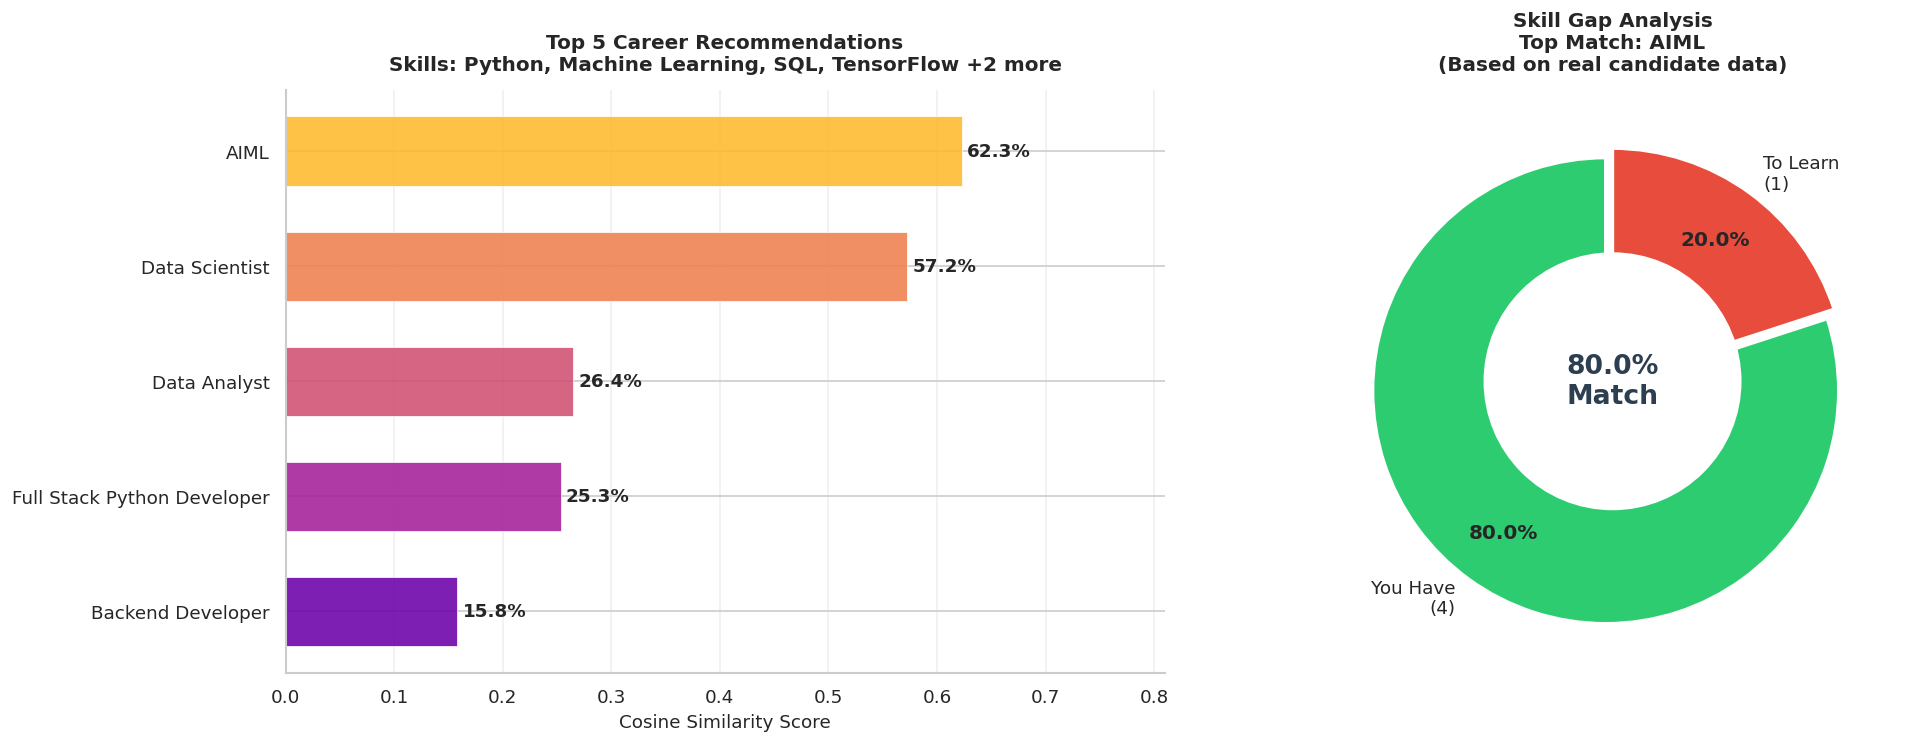

In [13]:
# YOUR FIRST RECOMMENDATION RUN
# ▶ CHANGE MY_SKILLS TO YOUR OWN SKILLS
#
# TIPS:
#   Skills must match what's in the dataset.
#   Common skills in dataset:
#   Python, SQL, Machine Learning, TensorFlow, Deep Learning,
#   JavaScript, React, HTML, CSS, Node.js, Docker, Kubernetes,
#   AWS, Linux, Java, Spring, Kotlin, Swift, iOS Development,
#   Penetration Testing, Figma, UI/UX Design, Agile, Scrum,
#   Solidity, Blockchain, PHP, Laravel, NLP, Data Analysis

MY_SKILLS = [
    "Python",
    "Machine Learning",
    "SQL",
    "TensorFlow",
    "Deep Learning",
    "Data Analysis",
]

TOP_N = 5

# RUN THE 4-STEP PIPELINE
print("=" * 60)
print("  🚀 RUNNING RECOMMENDATION ENGINE")
print("=" * 60)
print(f"\n  Your Skills  : {MY_SKILLS}")
print(f"  Dataset      : 1000 real candidates")
print(f"  Algorithm    : TF-IDF + Cosine Similarity")
print(f"  Pipeline     : Ingestion → Scoring → Sorting → Filtering\n")

results = get_recommendations(MY_SKILLS, top_n=TOP_N)

# DISPLAY RESULTS
print("=" * 60)
print("  📋 TOP RECOMMENDATIONS")
print("=" * 60)

for rank, (_, row) in enumerate(results.iterrows(), 1):
    bar     = "█" * int(row["similarity_score"] * 20)
    empty   = "░" * (20 - int(row["similarity_score"] * 20))
    print(f"\n  #{rank}  {row['job_role']}")
    print(f"      Match      : [{bar}{empty}] {row['match_pct']}")
    print(f"      Candidates : {row['candidate_count']} real records")

# SKILL GAP FOR TOP MATCH
top_role = results.iloc[0]["job_role"]
gap      = analyze_skill_gap(MY_SKILLS, top_role)
display_skill_gap(gap)

# VISUALIZE
visualize_recommendations(results, MY_SKILLS, gap)

In [14]:
# EXPERIENCE LEVEL FILTER

print("=" * 60)
print("  🎓 EXPERIENCE-FILTERED RECOMMENDATIONS")
print("=" * 60)

for level in ["Entry", "Mid", "Senior"]:
    print(f"\n  ── {level.upper()} LEVEL ──────────────────────────")
    filtered = get_recommendations(
        MY_SKILLS,
        top_n      = 3,
        experience = level
    )
    if filtered.empty:
        print(f"  No roles found for {level} level with these skills.")
    else:
        for rank, (_, row) in enumerate(filtered.iterrows(), 1):
            print(f"  #{rank}  {row['job_role']:<35} {row['match_pct']}")

  🎓 EXPERIENCE-FILTERED RECOMMENDATIONS

  ── ENTRY LEVEL ──────────────────────────
  #1  AIML                                62.3%
  #2  Data Scientist                      57.3%
  #3  Data Analyst                        26.4%

  ── MID LEVEL ──────────────────────────
  #1  AIML                                62.3%
  #2  Data Scientist                      57.3%
  #3  Data Analyst                        26.4%

  ── SENIOR LEVEL ──────────────────────────
  #1  AIML                                62.3%
  #2  Data Scientist                      57.3%
  #3  Data Analyst                        26.4%


In [15]:
# MULTI-PROFILE TESTING

test_profiles = {
    "🌐 Web Developer"      : ["JavaScript", "React", "HTML",
                                "CSS", "Node.js"],
    "☁️  DevOps Engineer"   : ["Docker", "Kubernetes", "AWS",
                                "Linux", "CI/CD"],
    "🔐 Security Analyst"   : ["Penetration Testing", "Firewalls",
                                "Network Security", "SIEM"],
    "📱 Mobile Developer"   : ["Swift", "iOS Development",
                                "Kotlin", "UI/UX Design"],
    "⛓️  Blockchain Dev"    : ["Solidity", "Ethereum",
                                "JavaScript", "Blockchain"],
}

print("=" * 60)
print("  MULTI-PROFILE PERSONALIZATION TEST")
print("=" * 60)

for profile_name, skills in test_profiles.items():
    print(f"\n  {profile_name}")
    print(f"  Skills: {skills}")
    print(f"  {'─'*50}")

    recs = get_recommendations(skills, top_n=3)
    for rank, (_, row) in enumerate(recs.iterrows(), 1):
        print(f"  #{rank}  {row['job_role']:<35} {row['match_pct']}")

print("\n\n Every profile returned different top recommendations.")
print("   Personalization engine confirmed working.")

  MULTI-PROFILE PERSONALIZATION TEST

  🌐 Web Developer
  Skills: ['JavaScript', 'React', 'HTML', 'CSS', 'Node.js']
  ──────────────────────────────────────────────────
  #1  Frontend Developer                  75.8%
  #2  Web Developer                       68.0%
  #3  Full Stack Python Developer         18.1%

  ☁️  DevOps Engineer
  Skills: ['Docker', 'Kubernetes', 'AWS', 'Linux', 'CI/CD']
  ──────────────────────────────────────────────────
  #1  Kubernetes Operations Engineer      73.1%
  #2  DevOps Engineer                     47.6%
  #3  Full Stack Java Developer           21.6%

  🔐 Security Analyst
  Skills: ['Penetration Testing', 'Firewalls', 'Network Security', 'SIEM']
  ──────────────────────────────────────────────────
  #1  Cybersecurity Engineer              89.9%
  #2  Web Developer                       0.0%
  #3  Software Project Manager            0.0%

  📱 Mobile Developer
  Skills: ['Swift', 'iOS Development', 'Kotlin', 'UI/UX Design']
  ──────────────────────────

In [16]:
# COLD START TEST

print("=" * 60)
print("  🧊 COLD START TEST")
print("=" * 60)
print("\n  Simulating brand-new user with NO skills...\n")

cold = get_recommendations(user_skills=[], top_n=5)
display(cold[["job_role", "candidate_count", "similarity_score"]])

print("\n Cold Start handled gracefully.")
print("   Fallback: Most popular roles by candidate count.")
print("   No crash. No zero-vector error.")

  🧊 COLD START TEST

  Simulating brand-new user with NO skills...

⚠  No skills provided — Cold Start detected.
   Returning most popular roles as fallback...



,job_role,candidate_count,similarity_score
17,Mobile Developer,75,N/A (Popular)
1,Backend Developer,50,N/A (Popular)
2,Blockchain Developer,50,N/A (Popular)
3,C# Developer,50,N/A (Popular)
4,Cybersecurity Engineer,50,N/A (Popular)



 Cold Start handled gracefully.
   Fallback: Most popular roles by candidate count.
   No crash. No zero-vector error.


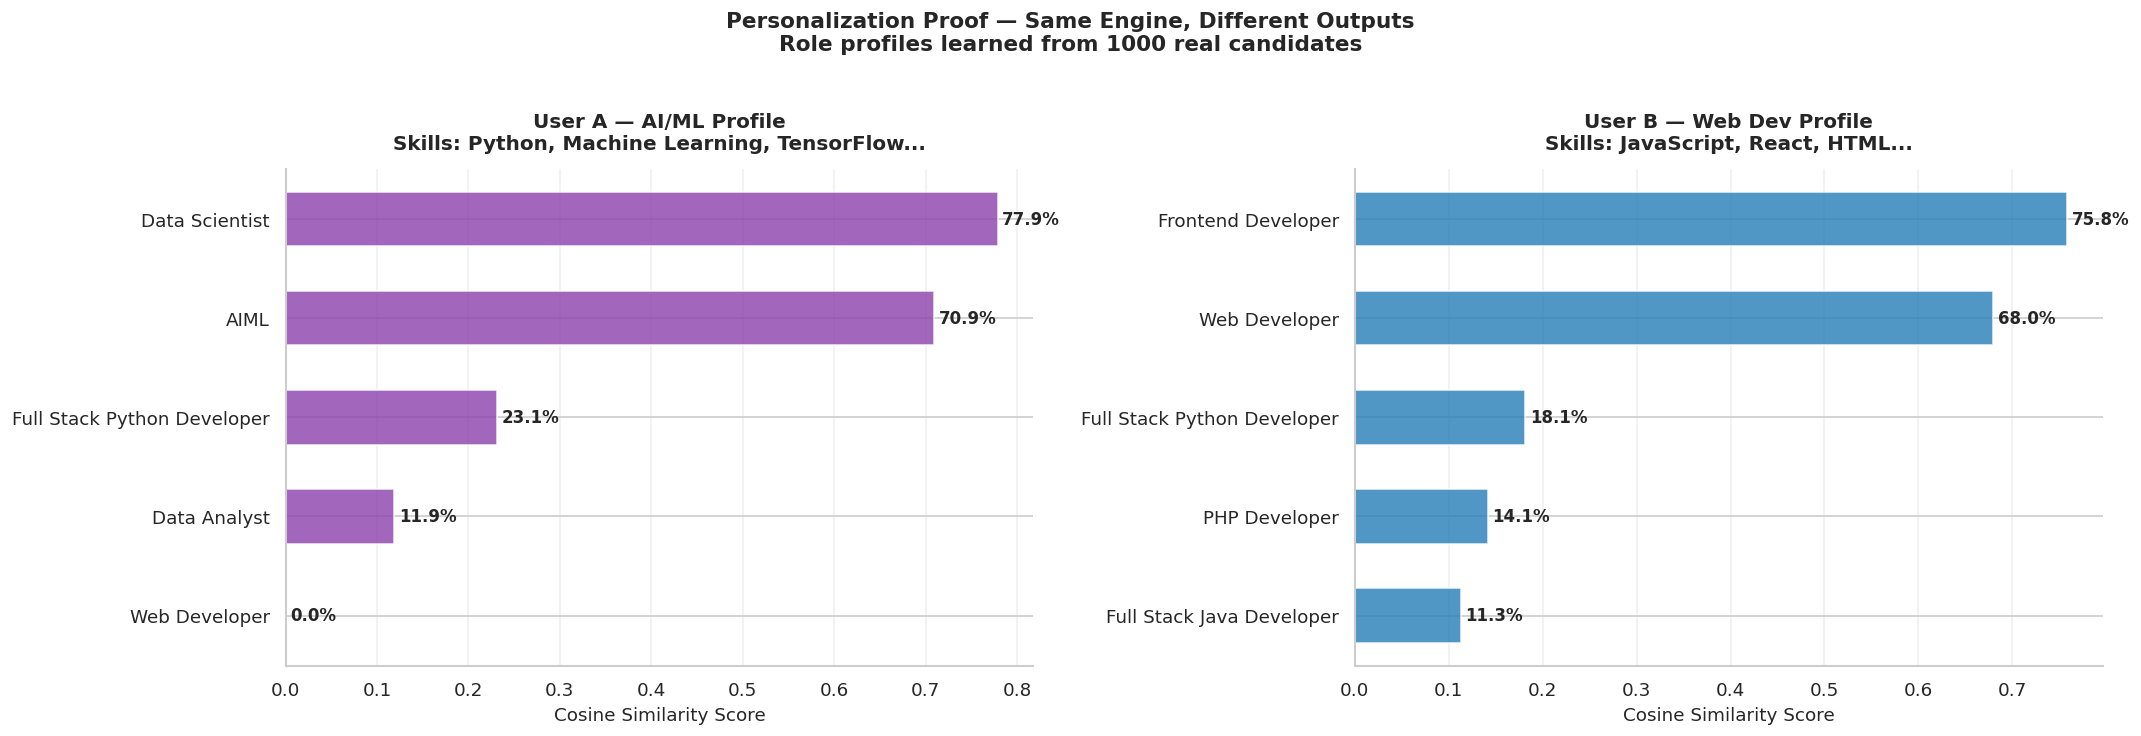

In [17]:
# TWO-USER COMPARISON

user_a = ["Python", "Machine Learning", "TensorFlow", "NLP"]
user_b = ["JavaScript", "React", "HTML", "CSS", "Node.js"]

recs_a = get_recommendations(user_a, top_n=5)
recs_b = get_recommendations(user_b, top_n=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for ax, recs, label, skills, color in [
    (ax1, recs_a, "User A — AI/ML Profile",    user_a, "#8E44AD"),
    (ax2, recs_b, "User B — Web Dev Profile",   user_b, "#2980B9"),
]:
    roles  = recs["job_role"].tolist()
    scores = recs["similarity_score"].tolist()

    bars = ax.barh(
        roles[::-1], scores[::-1],
        color=color, alpha=0.82,
        height=0.55, edgecolor="white"
    )
    for bar, score in zip(bars, scores[::-1]):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{score*100:.1f}%",
            va="center", fontsize=10, fontweight="bold"
        )

    ax.set_title(
        f"{label}\nSkills: {', '.join(skills[:3])}...",
        fontsize=12, fontweight="bold", pad=12
    )
    ax.set_xlabel("Cosine Similarity Score", fontsize=11)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle(
    "Personalization Proof — Same Engine, Different Outputs\n"
    "Role profiles learned from 1000 real candidates",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("comparison.png", dpi=120, bbox_inches="tight")
plt.show()

  🌟 PERSONAL CAREER RECOMMENDATION FOR KASHAF
  Powered by 1000 real candidate records

  Based on your 7 skills:
    ✦ Python
    ✦ Machine Learning
    ✦ Deep Learning
    ✦ SQL
    ✦ Data Analysis
    ✦ TensorFlow
    ✦ NLP

  🏆 YOUR TOP CAREER MATCHES:

  🥇  AIML
      Match      : 76.9%
      Data Points: 25 real candidates

  🥈  Data Scientist
      Match      : 64.9%
      Data Points: 50 real candidates

  🥉  Data Analyst
      Match      : 24.4%
      Data Points: 50 real candidates

  4️⃣   Full Stack Python Developer
      Match      : 23.4%
      Data Points: 50 real candidates

  5️⃣   Backend Developer
      Match      : 14.6%
      Data Points: 50 real candidates

  🎯 SKILL GAP: AIML
     (Based on real candidate data)

  Top Skills Required : 5
  Skills You Have     : 5
  Coverage            : 100.0%

  ✅ MATCHED SKILLS (5):
     • Deep Learning
     • Machine Learning
     • Nlp
     • Python
     • Tensorflow

  ❌ SKILLS TO LEARN (0):

  💡 BONUS SKILLS YOU BRING (2):


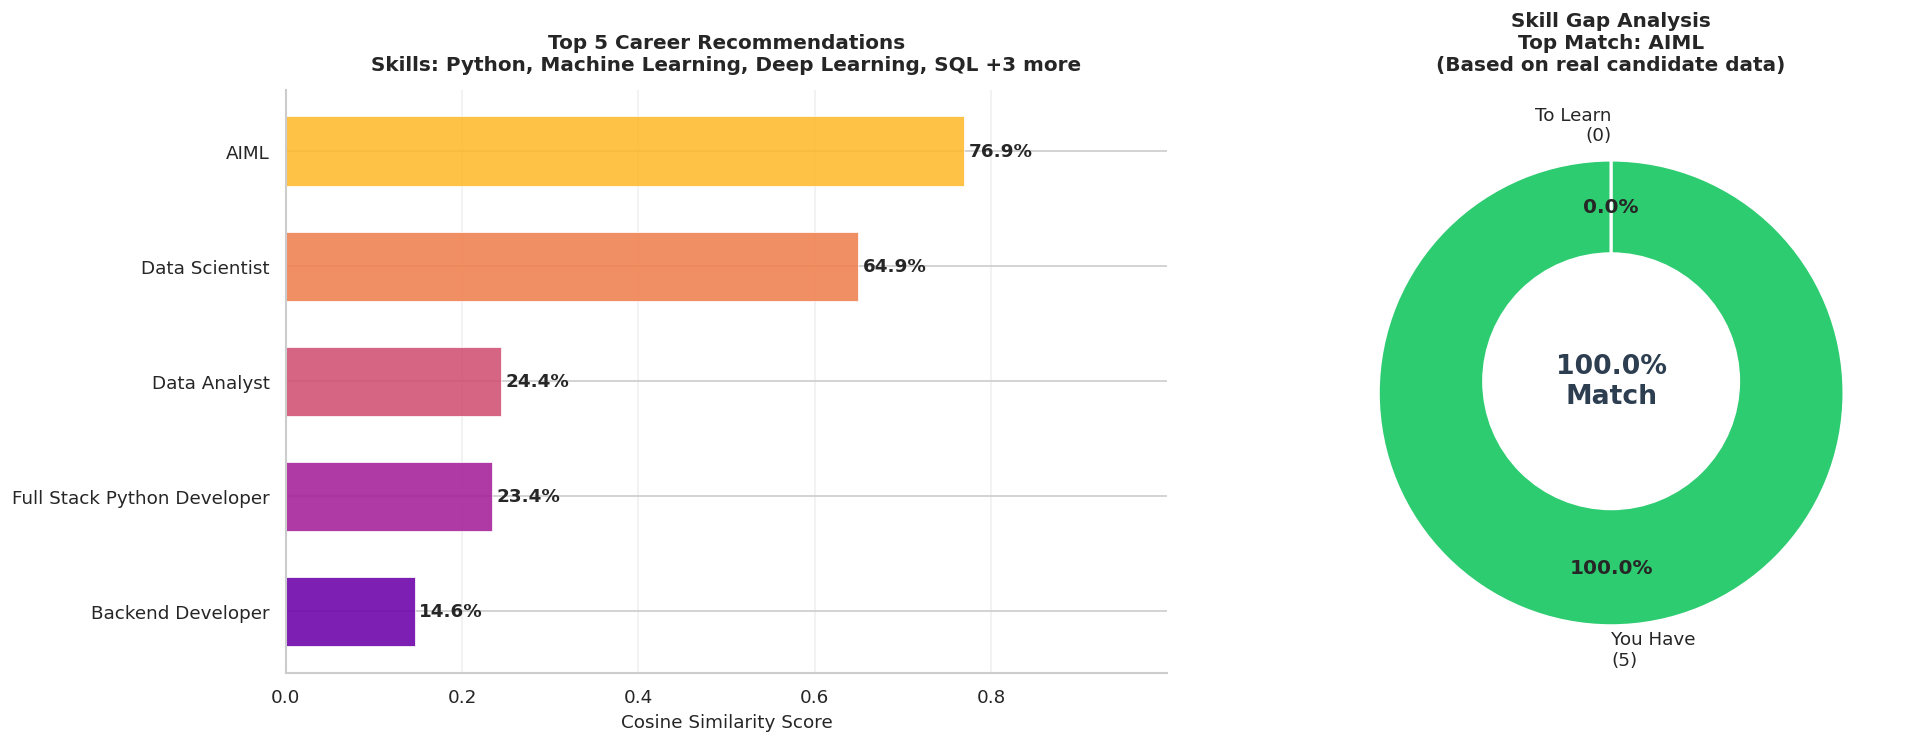

In [18]:
# YOUR PERSONAL CAREER RECOMMENDATION
# Enter YOUR actual skills here for the demo

YOUR_NAME   = "Kashaf"
YOUR_SKILLS = [
    "Python",
    "Machine Learning",
    "Deep Learning",
    "SQL",
    "Data Analysis",
    "TensorFlow",
    "NLP",
]

print("=" * 60)
print(f"  🌟 PERSONAL CAREER RECOMMENDATION FOR {YOUR_NAME.upper()}")
print(f"  Powered by 1000 real candidate records")
print("=" * 60)

my_results = get_recommendations(YOUR_SKILLS, top_n=5)

print(f"\n  Based on your {len(YOUR_SKILLS)} skills:")
for s in YOUR_SKILLS:
    print(f"    ✦ {s}")

print(f"\n  🏆 YOUR TOP CAREER MATCHES:\n")
medals = ["🥇","🥈","🥉","4️⃣ ","5️⃣ "]
for rank, (_, row) in enumerate(my_results.iterrows(), 1):
    print(f"  {medals[rank-1]}  {row['job_role']}")
    print(f"      Match      : {row['match_pct']}")
    print(f"      Data Points: {row['candidate_count']} real candidates\n")

top       = my_results.iloc[0]["job_role"]
my_gap    = analyze_skill_gap(YOUR_SKILLS, top)
display_skill_gap(my_gap)
visualize_recommendations(my_results, YOUR_SKILLS, my_gap)